# Simulating the Repressilator: A Synthetic Oscillatory Network

This project reproduces and analyzes the repressilator model introduced in:

Elowitz, M.B. and Leibler, S., (2000). *A synthetic oscillatory network of transcriptional regulators.*, Nature, 403(6767), pp.335-338.

The repressilator is a synthetic genetic regulatory network consisting of three genes arranged in a cyclic inhibitory feedback loop. This negative feedback can lead to sustained oscillations in protein concentrations.

While the full mathematical derivation, steady-state assumptions, and linear stability analysis (including the Jacobian and Hopf bifurcation conditions) are detailed in the repository's `README.md`, this notebook focuses entirely on numerically simulating the system to observe the resulting dynamics.

## The Dynamical Model

The network is modeled using a system of six coupled ordinary differential equations (ODEs)—three representing mRNA transcripts ($m_i$) and three representing their corresponding proteins ($p_i$):

$$\frac{dm_i}{dt} = -m_i + \frac{\alpha}{1 + p_j^n} + \alpha_0$$
$$\frac{dp_i}{dt} = -\beta(p_i - m_i)$$

**Parameters:**
* $i \in \{lacI, tetR, cI\}$ and $j$ represents the preceding repressor in the loop.
* $\alpha$: Maximum promoter activity (transcription rate).
* $\alpha_0$: Leakiness of the promoter (basal transcription).
* $\beta$: Ratio of protein decay rate to mRNA decay rate.
* $n$: Hill coefficient (cooperativity of repressor binding).

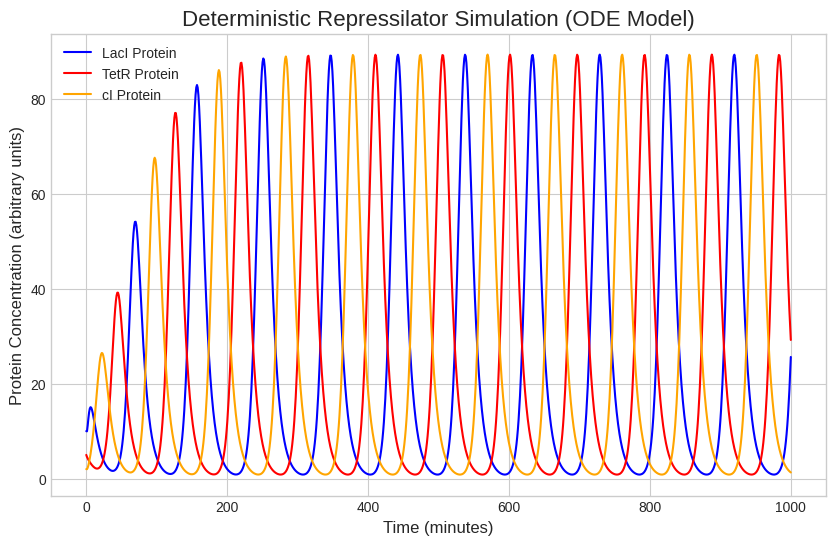

In [ ]:
import numpy as np
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt

# --- 1. Define the ODE system for the repressilator ---
def repressilator_ode(t, y, alpha, alpha0, beta, n):
    """
    Defines the system of differential equations for the repressilator.

    Args:
        t: Time (not used directly, but required by the solver).
        y: Array of current concentrations [m_L, m_T, m_C, p_L, p_T, p_C].
           (m = mRNA, p = protein; L = LacI, T = TetR, C = cI)
        alpha, alpha0, beta, n: Model parameters.
    """
    m_L, m_T, m_C, p_L, p_T, p_C = y

    # Repression logic: LacI represses TetR, TetR represses cI, cI represses LacI
    # So, the production of m_T is repressed by p_L, m_C by p_T, and m_L by p_C.

    # mRNA rates of change
    dmL_dt = -m_L + alpha / (1 + p_C**n) + alpha0
    dmT_dt = -m_T + alpha / (1 + p_L**n) + alpha0
    dmC_dt = -m_C + alpha / (1 + p_T**n) + alpha0

    # Protein rates of change
    dpL_dt = -beta * (p_L - m_L)
    dpT_dt = -beta * (p_T - m_T)
    dpC_dt = -beta * (p_C - m_C)

    return [dmL_dt, dmT_dt, dmC_dt, dpL_dt, dpT_dt, dpC_dt]


# --- 2. Set model parameters ---
# These values are derived from Box 1 and Figure 1 of the paper.
# The 'X' in Fig 1b is in a region consistent with these parameters.
alpha = 216      # Dimensionless transcription rate
alpha0 = 1e-4    # Leaky transcription rate
beta = 0.2       # Ratio of protein to mRNA decay rates (2min/10min)
n = 2.0          # Hill coefficient for repression cooperativity

# --- 3. Set simulation conditions ---
# Initial conditions: [m_L, m_T, m_C, p_L, p_T, p_C]
# Start with some proteins present to kickstart the system
y0 = [0, 0, 0, 10, 5, 2]

# Time span for the simulation (in units of mRNA lifetime, ~2 min)
# A span of 500 corresponds to 1000 minutes, matching the paper's plot.
t_span = [0, 500]
t_eval = np.linspace(t_span[0], t_span[1], 1000)

# --- 4. Run the ODE solver ---
sol = solve_ivp(
    fun=repressilator_ode,
    t_span=t_span,
    y0=y0,
    args=(alpha, alpha0, beta, n),
    dense_output=True,
    t_eval=t_eval
)

# --- 5. Plot the results ---
plt.style.use('seaborn-v0_8-whitegrid')
fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(sol.t * 2, sol.y[3], label='LacI Protein', color='blue')
ax.plot(sol.t * 2, sol.y[4], label='TetR Protein', color='red')
ax.plot(sol.t * 2, sol.y[5], label='cI Protein', color='orange')

ax.set_title('Deterministic Repressilator Simulation (ODE Model)', fontsize=16)
ax.set_xlabel('Time (minutes)', fontsize=12)
ax.set_ylabel('Protein Concentration (arbitrary units)', fontsize=12)
ax.legend()
ax.grid(True)
plt.show()

The trajectories show sustained oscillations in the protein concentrations.  
This corresponds to a **limit cycle behavior** predicted by the repressilator model.

Oscillations arise due to delayed negative feedback in the three-gene regulatory loop.

## Bifurcation Analysis, Stability Diagram and Time Series Simulation

To understand the conditions under which the repressilator exhibits sustained oscillations, we must examine the parameter space of $\alpha$ (maximum promoter activity) and $\beta$ (ratio of protein to mRNA lifetimes). 

The following code calculates the stability boundaries for the steady state. Crossing these boundaries corresponds to a **Hopf bifurcation**, where the stable fixed point becomes unstable, giving rise to a stable limit cycle (oscillations). The curves below represent this boundary for different Hill coefficients ($n$) and leakiness ratios ($\alpha_0/\alpha$).

Having mapped the parameter space, we can select parameters that fall within the unstable, oscillatory regime (e.g., $\alpha=100$, $\beta=10$, $n=2$). 

Below, we numerically integrate the system of ordinary differential equations using `scipy.integrate.solve_ivp`. The resulting time series clearly demonstrates the characteristic, out-of-phase oscillations of the three repressor proteins.

Generating Corrected Figure 1b: Stability Diagram...


/tmp/ipython-input-3959764397.py:21: RuntimeWarning: invalid value encountered in power
  equation = lambda p: p - alpha / (1 + p**n) - alpha_0


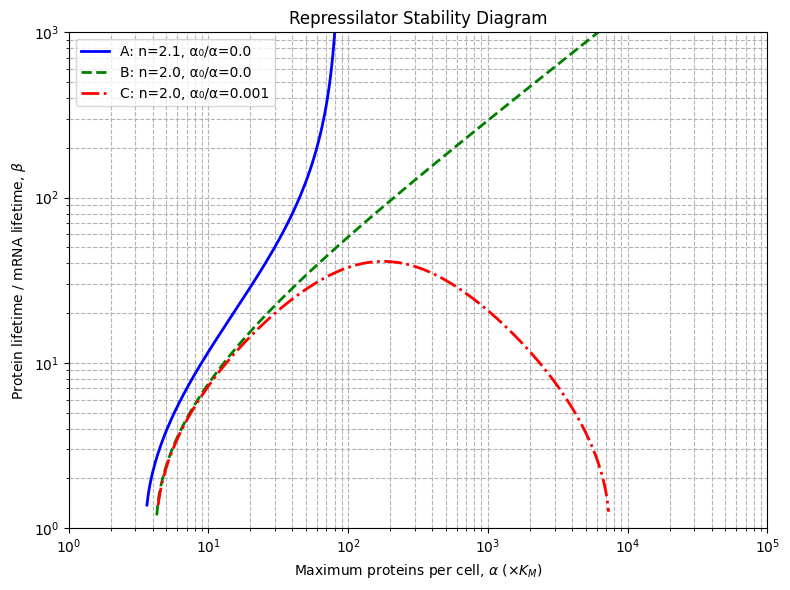


Generating Figure 1c: Time Series Simulation...


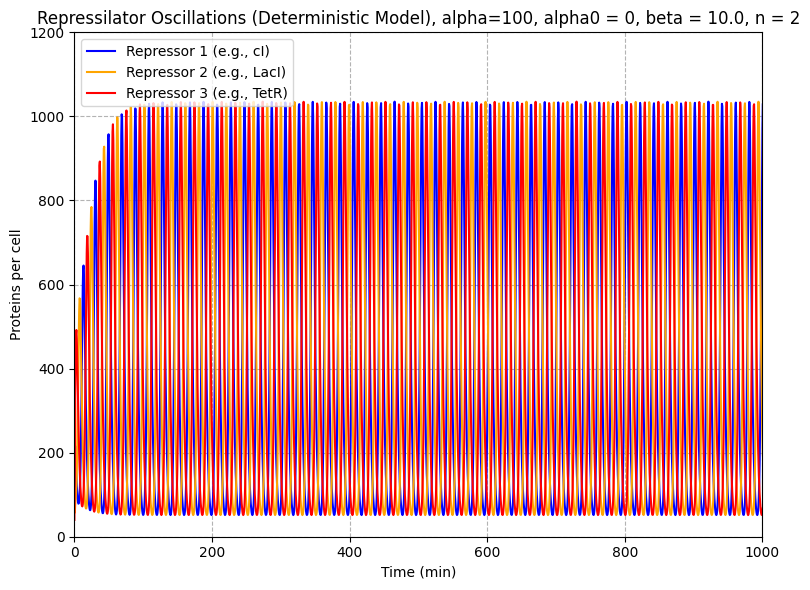

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from scipy.optimize import fsolve

def plot_stability_diagram():
    """
    Generates the corrected stability diagram by implementing the full analytical
    solution for the stability boundary, and correctly handling plotting across
    vertical asymptotes.
    """
    print("Generating Corrected Figure 1b: Stability Diagram...")

    # --- Helper functions based on the correct mathematical derivation ---

    def solve_steady_state_p(alpha, n, alpha_0):
        """
        Numerically solves the steady-state equation for p:
        p - alpha / (1 + p^n) - alpha_0 = 0
        """
        equation = lambda p: p - alpha / (1 + p**n) - alpha_0
        # Use a reasonable starting guess and check for convergence
        p_solution, _, converged, _ = fsolve(equation, x0=alpha, full_output=True)
        return p_solution[0] if converged and p_solution[0] > 0 else np.nan

    def calculate_beta_on_boundary(alpha, n, alpha_0):
        """
        Calculates the two values of beta on the stability boundary for a given alpha.
        The system is unstable between these two beta values.
        """
        p = solve_steady_state_p(alpha, n, alpha_0)
        if np.isnan(p):
            return np.nan, np.nan

        # Calculate the intermediate variable X = f'(p)
        X = -(alpha * n * p**(n - 1)) / (1 + p**n)**2

        # For real solutions for beta to exist, a condition which simplifies to X <= -4/3 must be met.
        if X > -4/3:
            return np.nan, np.nan

        # A singularity exists at X = -2. This is handled by checking the denominator of K.
        # If the denominator (4 + 2*X) is close to zero, we are at the asymptote.
        if abs(4 + 2 * X) < 1e-3:
            return np.nan, np.nan

        # Let K = 3*X^2 / (4 + 2*X). The boundary is defined by beta^2 + (2-K)*beta + 1 = 0
        K = (3 * X**2) / (4 + 2 * X)

        # This check is now mostly redundant but kept for safety.
        if K < 0 and n < 2.01: # For n > 2, K can be negative, leading to positive beta roots.
            pass
        elif (2-K)**2 < 4:
            return np.nan, np.nan

        discriminant = (2 - K)**2 - 4

        sqrt_discriminant = np.sqrt(discriminant)

        # The two roots of the quadratic equation for beta
        beta1 = (-(2 - K) + sqrt_discriminant) / 2
        beta2 = (-(2 - K) - sqrt_discriminant) / 2

        return beta1, beta2

    # --- Main Plotting Routine ---

    fig, ax = plt.subplots(figsize=(8, 6))
    alpha_range = np.logspace(0, 10, 1000) # Increased points for smoother curve

    # Define parameters for the three curves with different colors and styles
    params = {
        'A': {'n': 2.1, 'alpha_0_ratio': 0.0, 'style': 'b-', 'lw': 2},    # Blue solid line
        'B': {'n': 2.0, 'alpha_0_ratio': 0.0, 'style': 'g--', 'lw': 2},   # Green dashed line
        'C': {'n': 2.0, 'alpha_0_ratio': 1e-3, 'style': 'r-.', 'lw': 2}   # Red dash-dot line
    }

    for label, p in params.items():
        # Calculate beta values for the entire alpha range, inserting NaNs for discontinuities
        betas1_all = []
        betas2_all = []
        for alpha in alpha_range:
            alpha_0 = p['alpha_0_ratio'] * alpha
            b1, b2 = calculate_beta_on_boundary(alpha, p['n'], alpha_0)

            if not (np.isnan(b1) or np.isnan(b2)):
                # Ensure beta is positive and real
                if isinstance(b1, complex) or isinstance(b2, complex) or b1 < 0 or b2 < 0:
                    betas1_all.append(np.nan)
                    betas2_all.append(np.nan)
                else:
                    betas1_all.append(min(b1, b2))
                    betas2_all.append(max(b1, b2))
            else:
                betas1_all.append(np.nan)
                betas2_all.append(np.nan)

        # Convert to numpy arrays
        betas1_all = np.array(betas1_all)
        betas2_all = np.array(betas2_all)

        # Plot the lower and upper boundaries. Matplotlib correctly handles NaN gaps.
        # The color is now taken from the 'style' key in the params dictionary
        ax.plot(alpha_range, betas1_all, p['style'], lw=p['lw'], label=f'{label}: n={p["n"]}, α₀/α={p["alpha_0_ratio"]}')
        ax.plot(alpha_range, betas2_all, p['style'], lw=p['lw'])

    # --- Shaded region has been removed ---

    # --- Formatting ---
    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.set_xlim(1, 1e5)
    ax.set_ylim(1, 1e3)
    ax.set_xlabel(r'Maximum proteins per cell, $\alpha$ ($\times K_M$)')
    ax.set_ylabel(r'Protein lifetime / mRNA lifetime, $\beta$')
    ax.set_title('Repressilator Stability Diagram')

    ax.legend()
    ax.grid(True, which="both", ls="--", c='0.7')
    plt.tight_layout()
    plt.show()


def simulate_oscillations():
    """
    Solves the ODEs for the repressilator to generate the time-series plot
    of protein concentrations, similar to Figure 1c (left panel).
    This function was correct and remains unchanged.
    """
    print("\nGenerating Figure 1c: Time Series Simulation...")

    # --- Model Parameters ---
    alpha = 100
    alpha0 = 0
    beta = 10.00
    n = 2

    # --- ODE System Definition ---
    def repressilator(t, y):
        m1, p1, m2, p2, m3, p3 = y
        dm1_dt = -m1 + alpha / (1 + p3**n) + alpha0
        dm2_dt = -m2 + alpha / (1 + p1**n) + alpha0
        dm3_dt = -m3 + alpha / (1 + p2**n) + alpha0
        dp1_dt = -beta * (p1 - m1)
        dp2_dt = -beta * (p2 - m2)
        dp3_dt = -beta * (p3 - m3)
        return [dm1_dt, dp1_dt, dm2_dt, dp2_dt, dm3_dt, dp3_dt]

    # --- Simulation Setup ---
    y0 = [0, 2, 0, 1, 0, 3]
    t_span_dim = [0, 400]
    t_eval_dim = np.linspace(t_span_dim[0], t_span_dim[1], 2000)

    # --- Solve the ODEs ---
    sol = solve_ivp(repressilator, t_span_dim, y0, t_eval=t_eval_dim, dense_output=True)

    # --- Process and Plot Results ---
    Km = 40
    mRNA_half_life = 2.0
    time_conversion_factor = mRNA_half_life / np.log(2)

    time_minutes = sol.t * time_conversion_factor
    p_lacI = sol.y[1] * Km
    p_tetR = sol.y[3] * Km
    p_cI = sol.y[5] * Km

    fig, ax = plt.subplots(figsize=(8, 6))

    ax.plot(time_minutes, p_cI, color='blue', label='Repressor 1 (e.g., cI)')
    ax.plot(time_minutes, p_lacI, color='orange', label='Repressor 2 (e.g., LacI)')
    ax.plot(time_minutes, p_tetR, color='red', label='Repressor 3 (e.g., TetR)')

    ax.set_xlabel('Time (min)')
    ax.set_ylabel('Proteins per cell')
    ax.set_title(f'Repressilator Oscillations (Deterministic Model), alpha={alpha}, alpha0 = {alpha0}, beta = {beta}, n = {n}')
    ax.legend()
    ax.grid(True, which="both", ls="--", c='0.7')
    ax.set_xlim(0, 1000)
    ax.set_ylim(0, 1200)

    plt.tight_layout()
    plt.show()


if __name__ == '__main__':
    plot_stability_diagram()
    simulate_oscillations()


## Bifurcation Analysis: Onset of Oscillations

To visualize the transition from a stable fixed point to sustained oscillations, we can construct a **bifurcation diagram**. 

Here, we treat the maximum transcription rate ($\alpha$) as our control parameter. For each value of $\alpha$, we simulate the system, allow any initial transients to decay, and plot the local extrema (maxima and minima) of the resulting protein concentration. 
* A single line indicates a stable steady state.
* A splitting into upper and lower branches indicates a stable limit cycle (oscillations), marking the **Hopf bifurcation**.

Simulating parameter sweeps for the bifurcation diagram. This may take a moment...


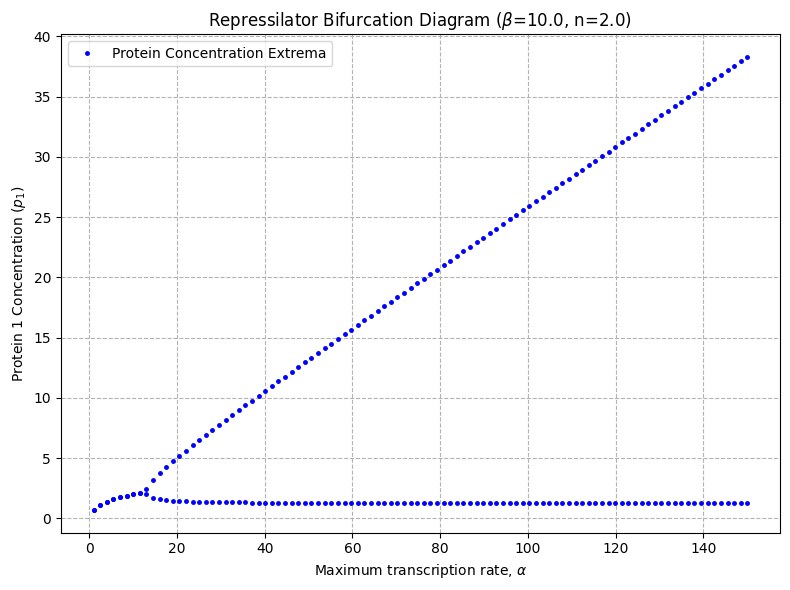

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from scipy.signal import find_peaks

def repressilator_ode(t, y, alpha, beta, n, alpha0):
    """The ODE system for the repressilator to be used in the loop."""
    m1, p1, m2, p2, m3, p3 = y
    dm1_dt = -m1 + alpha / (1 + p3**n) + alpha0
    dm2_dt = -m2 + alpha / (1 + p1**n) + alpha0
    dm3_dt = -m3 + alpha / (1 + p2**n) + alpha0
    dp1_dt = -beta * (p1 - m1)
    dp2_dt = -beta * (p2 - m2)
    dp3_dt = -beta * (p3 - m3)
    return [dm1_dt, dp1_dt, dm2_dt, dp2_dt, dm3_dt, dp3_dt]

def plot_bifurcation_diagram():
    print("Simulating parameter sweeps for the bifurcation diagram. This may take a moment...")
    
    # Define our parameter space
    alpha_values = np.linspace(1, 150, 100)
    beta = 10.0
    n = 2.0
    alpha0 = 0.0
    
    p1_maxima = []
    p1_minima = []
    alpha_plot = []

    # Time span: long enough to ensure transients die out
    t_span = [0, 500]
    t_eval = np.linspace(t_span[0], t_span[1], 5000)
    y0 = [0, 2, 0, 1, 0, 3] 

    for alpha in alpha_values:
        sol = solve_ivp(repressilator_ode, t_span, y0, args=(alpha, beta, n, alpha0), 
                        t_eval=t_eval, dense_output=False)
        
        # Discard the first 70% of the simulation to remove transients
        transient_cutoff = int(0.7 * len(sol.t))
        p1_steady = sol.y[1][transient_cutoff:]
        
        # Find local maxima (peaks) and minima (valleys)
        peaks, _ = find_peaks(p1_steady)
        valleys, _ = find_peaks(-p1_steady)
        
        # If oscillations exist, plot the amplitude bounds
        if len(peaks) > 0 and len(valleys) > 0:
            max_val = np.mean(p1_steady[peaks])
            min_val = np.mean(p1_steady[valleys])
            p1_maxima.append(max_val)
            p1_minima.append(min_val)
            alpha_plot.append(alpha)
        else:
            # Stable fixed point: the system settles to a single value
            stable_val = p1_steady[-1]
            p1_maxima.append(stable_val)
            p1_minima.append(stable_val)
            alpha_plot.append(alpha)

    # Plotting the results
    fig, ax = plt.subplots(figsize=(8, 6))
    
    ax.plot(alpha_plot, p1_maxima, 'b.', markersize=5, label='Protein Concentration Extrema')
    ax.plot(alpha_plot, p1_minima, 'b.', markersize=5)
    
    ax.set_xlabel(r'Maximum transcription rate, $\alpha$')
    ax.set_ylabel(r'Protein 1 Concentration ($p_1$)')
    ax.set_title(rf'Repressilator Bifurcation Diagram ($\beta$={beta}, n={n})')
    ax.grid(True, which="both", ls="--", c='0.7')
    ax.legend()
    
    plt.tight_layout()
    plt.show()

# Execute the function
plot_bifurcation_diagram()

## Images in the Readme

Running numerical stability analysis on a grid...
Parameters: n=2.1, a0/a ratio=0.0
Grid size: 100 x 100 = 10000 points
Numerical analysis complete.
Calculating analytical stability boundary...
Analytical calculation complete.
Plotting combined results...


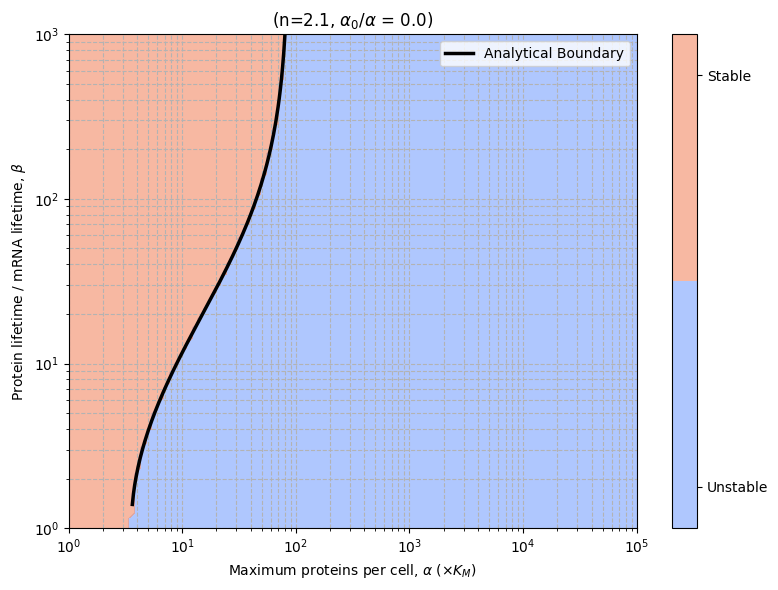

Done.


In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import brentq
from numpy.linalg import eigvals
import warnings

# ==========================================================
# ==========    Parameters you can change     ==========
# ==========================================================
n = 2.1          # Hill coefficient
a0_ratio = 0.0   # Set a0/a ratio (e.g., 0.0 or 0.001)

# Grid resolution for numerical map
grid_points_a = 100
grid_points_b = 100

# Resolution for the analytical curve
curve_points = 500
# ==========================================================

# ==========================================================
# ========== Helper Functions (from both scripts) ==========
# ==========================================================

# --- From Code 2: Robust root-finding for p* ---
def find_pstar(a, n, a0):
    """
    Numerically solves the steady-state equation for p:
    (1 + p^n)*(p - a0) = a
    using the robust brentq method.
    """
    def f(p):
        return (1 + p**n)*(p - a0) - a

    # Define a search bracket
    p_lower = a0
    # Find an upper bound that guarantees f(p_upper) > 0
    p_upper = max(a0 + 1.0, (a + 1.0)**(1.0/n)) * 1.5 # Start with a reasonable guess

    # Iteratively expand the upper bound if it's not a valid bracket
    max_iter = 10
    iter_count = 0
    while f(p_lower) * f(p_upper) >= 0 and iter_count < max_iter:
        p_upper *= 2.0
        iter_count += 1

    if iter_count == max_iter:
        # print(f"Warning: Could not find valid bracket for a={a}, a0={a0}")
        return np.nan

    try:
        with warnings.catch_warnings():
            warnings.simplefilter("ignore", RuntimeWarning)
            return brentq(f, p_lower, p_upper, maxiter=200)
    except Exception as e:
        # print(f"Warning: brentq failed for a={a}, a0={a0}. {e}")
        return np.nan # Return NaN if root finding fails

# --- From Code 1: Analytical solution for beta ---
def calculate_beta_on_boundary(alpha, n, alpha_0):
    """
    Calculates the two values of beta on the stability boundary for a given alpha.
    This version is modified to use 'find_pstar' from Code 2.
    """
    # Step 1: Find the steady-state p*
    p = find_pstar(alpha, n, alpha_0)
    if np.isnan(p) or p < 1e-9:
        return np.nan, np.nan

    # Step 2: Calculate the intermediate variable X = f'(p)
    # f(p) = alpha / (1 + p^n)
    X = -(alpha * n * p**(n - 1)) / (1 + p**n)**2

    # Step 3: Check stability condition. For real beta roots, we need X <= -4/3
    if X > -4/3:
        return np.nan, np.nan

    # Step 4: Handle the singularity at X = -2 (vertical asymptote)
    denominator = (4 + 2 * X)
    if abs(denominator) < 1e-6: # Avoid division by zero
        return np.nan, np.nan

    # Step 5: Calculate K and the discriminant
    K = (3 * X**2) / denominator
    discriminant = (2 - K)**2 - 4

    # Step 6: Check if discriminant is positive
    if discriminant < 0:
        return np.nan, np.nan

    # Step 7: Calculate the two beta roots
    sqrt_discriminant = np.sqrt(discriminant)
    beta1 = (-(2 - K) + sqrt_discriminant) / 2
    beta2 = (-(2 - K) - sqrt_discriminant) / 2

    # Ensure roots are positive
    if beta1 < 0 or beta2 < 0:
        return np.nan, np.nan

    return beta1, beta2

# --- From Code 2: Matrix for numerical stability ---
def mode_matrix(X, b, omega):
    return np.array([[-1.0, -X*omega],
                     [ b , -b]], dtype=complex)

# ==========================================================
# ==========     1. Numerical Grid Analysis     ==========
# ==========================================================

print("Running numerical stability analysis on a grid...")
print(f"Parameters: n={n}, a0/a ratio={a0_ratio}")
print(f"Grid size: {grid_points_a} x {grid_points_b} = {grid_points_a * grid_points_b} points")

a_vals = np.logspace(0, 5, grid_points_a) # 10^0 to 10^5
b_vals = np.logspace(0, 3, grid_points_b) # 10^0 to 10^3

stable = np.zeros((len(b_vals), len(a_vals)), dtype=bool)
max_re_eig = np.zeros_like(stable, dtype=float)

for ib, b in enumerate(b_vals):
    for ia, a in enumerate(a_vals):
        current_a0 = a0_ratio * a

        pstar = find_pstar(a, n, current_a0)

        if np.isnan(pstar):
            max_re_eig[ib, ia] = 0.0 # Treat as stable if p* not found
            stable[ib, ia] = True
            continue

        # We need X for the numerical analysis as well
        if pstar < 1e-9:
             X = 0.0
        else:
             X = (a * n * (pstar**(n-1))) / ((1 + pstar**n)**2)

        omegas = [1.0, np.exp(2j*np.pi/3), np.exp(-2j*np.pi/3)]
        all_eigs = []
        for omega in omegas:
            # Note: Code 2's 'X' definition is positive, Code 1's is negative.
            # The mode_matrix function from Code 2 expects X = |f'(p*)|
            Jk = mode_matrix(X, b, omega)
            eigs = eigvals(Jk)
            all_eigs.extend(eigs)

        all_eigs = np.array(all_eigs)
        max_re = np.max(np.real(all_eigs))

        if abs(max_re) < 1e-10:
             max_re = 0.0

        max_re_eig[ib, ia] = max_re
        stable[ib, ia] = (max_re <= 0.0)

print("Numerical analysis complete.")

# ==========================================================
# ==========    2. Analytical Curve Analysis    ==========
# ==========================================================
print("Calculating analytical stability boundary...")
a_curve = np.logspace(0, 5, curve_points)
betas1_curve = []
betas2_curve = []

for alpha in a_curve:
    current_a0 = a0_ratio * alpha
    b1, b2 = calculate_beta_on_boundary(alpha, n, current_a0)

    if not (np.isnan(b1) or np.isnan(b2)):
        betas1_curve.append(min(b1, b2))
        betas2_curve.append(max(b1, b2))
    else:
        betas1_curve.append(np.nan)
        betas2_curve.append(np.nan)

betas1_curve = np.array(betas1_curve)
betas2_curve = np.array(betas2_curve)
print("Analytical calculation complete.")

# ==========================================================
# ==========         3. Plotting Results        ==========
# ==========================================================
print("Plotting combined results...")

A, B = np.meshgrid(a_vals, b_vals)
plt.figure(figsize=(8, 6))

# --- Plot the numerical stability map (shaded regions) ---
# 'coolwarm' cmap: red = unstable (stable=False=0), blue = stable (stable=True=1)
plt.contourf(A, B, stable, levels=[-0.1, 0.5, 1.1], cmap='coolwarm', alpha=0.7)
cb = plt.colorbar(ticks=[0, 1])
cb.set_ticklabels(['Unstable', 'Stable'])

# --- Plot the analytical boundary (solid lines) ---
plt.plot(a_curve, betas1_curve, 'k-', lw=2.5, label='Analytical Boundary')
plt.plot(a_curve, betas2_curve, 'k-', lw=2.5)

# --- Formatting ---
plt.xlabel(r'Maximum proteins per cell, $\alpha$ ($\times K_M$)')
plt.ylabel(r'Protein lifetime / mRNA lifetime, $\beta$')
title_str = r'(n={n}, $\alpha_0 / \alpha$ = {a0_ratio})'.format(n=n, a0_ratio=a0_ratio)
plt.title(title_str)

plt.yscale('log')
plt.xscale('log')
plt.ylim(1, 1e3)
plt.xlim(1, 1e5)
plt.legend()
plt.grid(True, which="both", ls="--", c='0.7')
plt.tight_layout()
plt.show()

print("Done.")


--- System Parameters ---
alpha = 10000, alpha0 = 0.0, beta = 10.0, n = 2.1
Calculated symmetric fixed point: p* = 19.5007, m* = 19.5007
Initial conditions (y0): [np.float64(19.500651434888987), np.float64(19.600651434888988), np.float64(19.500651434888987), np.float64(19.500651434888987), np.float64(19.500651434888987), np.float64(19.500651434888987)]

Solving ODEs...
Simulation complete.


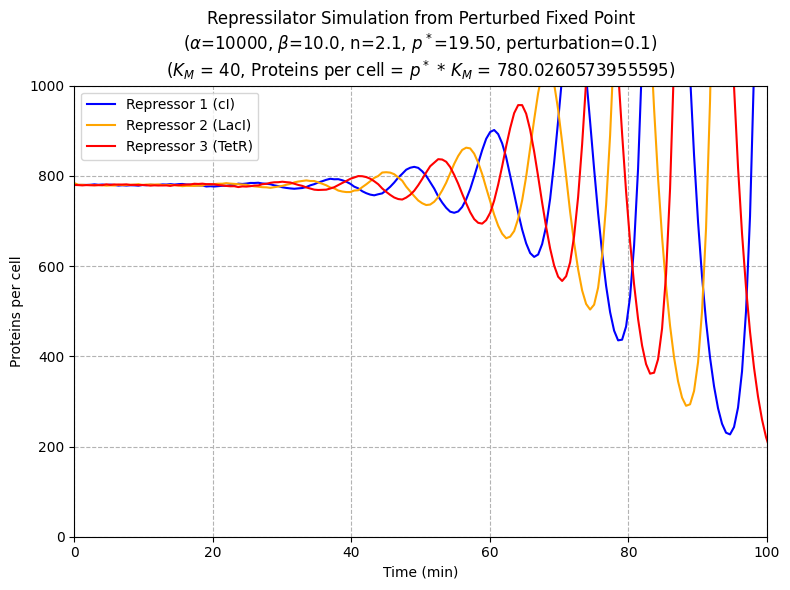

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from scipy.optimize import fsolve

def solve_steady_state_p(alpha, n, alpha_0):
    """
    Numerically solves the steady-state equation for the symmetric fixed point p:
    p - alpha / (1 + p^n) - alpha_0 = 0
    """
    equation = lambda p: p - alpha / (1 + p**n) - alpha_0

    # Use a robust starting guess. 1.0 is often safe.
    p_solution, _, converged, _ = fsolve(equation, x0=1.0, full_output=True)

    if converged and p_solution[0] >= 0:
        return p_solution[0]
    else:
        # Try another guess if the first one failed (e.g., for high alpha)
        p_solution, _, converged, _ = fsolve(equation, x0=alpha, full_output=True)
        if converged and p_solution[0] >= 0:
            return p_solution[0]
        else:
            print("Warning: Fixed point solver did not converge.")
            return np.nan

def repressilator_ode(t, y, alpha, alpha0, beta, n):
    """
    Defines the ODE system for the repressilator.
    y = [m1, p1, m2, p2, m3, p3]
    """
    m1, p1, m2, p2, m3, p3 = y

    dm1_dt = -m1 + alpha / (1 + p3**n) + alpha0
    dm2_dt = -m2 + alpha / (1 + p1**n) + alpha0
    dm3_dt = -m3 + alpha / (1 + p2**n) + alpha0

    dp1_dt = -beta * (p1 - m1)
    dp2_dt = -beta * (p2 - m2)
    dp3_dt = -beta * (p3 - m3)

    return [dm1_dt, dp1_dt, dm2_dt, dp2_dt, dm3_dt, dp3_dt]

def simulate_from_fixed_point():
    """
    Calculates the fixed point, perturbs it, and simulates the time series.
    """

    # --- 1. Model Parameters ---
    # These parameters are in the unstable (oscillatory) region
    rat = 0.0 # as in the phase space alpha_0/alpha
    n = 2.1

    alpha = 10000
    beta = 10.0

    alpha0 = rat * alpha
    perturbation = 0.1  # The "tolerance" you requested

    # --- 2. Calculate the Fixed Point ---
    # At steady state, m = p. The symmetric fixed point is p*
    p_star = solve_steady_state_p(alpha, n, alpha0)
    m_star = p_star  # At steady state, m* = p*

    if np.isnan(p_star):
        print("Error: Could not find fixed point. Exiting.")
        return

    print(f"--- System Parameters ---")
    print(f"alpha = {alpha}, alpha0 = {alpha0}, beta = {beta}, n = {n}")
    print(f"Calculated symmetric fixed point: p* = {p_star:.4f}, m* = {m_star:.4f}")

    # --- 3. Set Initial Conditions near the Fixed Point ---
    # y = [m1, p1, m2, p2, m3, p3]
    # We start all states at the fixed point, then "kick" p1
    y0 = [
        m_star, p_star + perturbation,  # (m1, p1)
        m_star, p_star,                  # (m2, p2)
        m_star, p_star                   # (m3, p3)
    ]

    print(f"Initial conditions (y0): {y0}")

    # --- 4. Simulation Setup ---
    t_span_dim = [0, 400]  # Time in dimensionless units
    t_eval_dim = np.linspace(t_span_dim[0], t_span_dim[1], 2000)

    # --- 5. Solve the ODEs ---
    print("\nSolving ODEs...")
    sol = solve_ivp(
        repressilator_ode,
        t_span_dim,
        y0,
        t_eval=t_eval_dim,
        args=(alpha, alpha0, beta, n), # Pass parameters to the ODE function
        method='RK45'  # A standard, robust solver
    )
    print("Simulation complete.")

    # --- 6. Process and Plot Results ---
    # (These conversion factors are from your original code)
    Km = 40.0
    mRNA_half_life = 2.0
    time_conversion_factor = mRNA_half_life / np.log(2)

    time_minutes = sol.t * time_conversion_factor

    # Map variables to the repressors as in your original 'simulate_oscillations'
    p_lacI = sol.y[1] * Km  # p1
    p_tetR = sol.y[3] * Km  # p2
    p_cI   = sol.y[5] * Km  # p3

    fig, ax = plt.subplots(figsize=(8, 6))

    # Plot using the labels from your original code for consistency
    ax.plot(time_minutes, p_cI,   color='blue',   label='Repressor 1 (cI)')
    ax.plot(time_minutes, p_lacI, color='orange', label='Repressor 2 (LacI)')
    ax.plot(time_minutes, p_tetR, color='red',    label='Repressor 3 (TetR)')

    ax.set_xlabel('Time (min)')
    ax.set_ylabel('Proteins per cell')
    title = (f'Repressilator Simulation from Perturbed Fixed Point\n'
             f'($\\alpha$={alpha}, $\\beta$={beta}, n={n}, $p^*$={p_star:.2f}, perturbation={perturbation})\n'
             f'($K_M$ = 40, Proteins per cell = $p^*$ * $K_M$ = {p_star * 40})')
    ax.set_title(title)
    ax.legend()
    ax.grid(True, which="both", ls="--", c='0.7')

    # Adjust plot limits to show the behavior
    ax.set_xlim(0, 100) # Use x-lim from original code for consistency
    ax.set_ylim(0,1000) # Use y-lim from original code for consistency

    plt.tight_layout()
    plt.show()

# --- Run the simulation ---
if __name__ == '__main__':
    simulate_from_fixed_point()